# 🏆 Notebook 4 — Model Comparison & Final Conclusions
**Dataset:** Life Expectancy (WHO)

This notebook loads all saved predictions and produces a unified comparison:
1. MSE / R² / RMSE / MAE table
2. Bar chart — MSE comparison
3. Bar chart — R² comparison
4. Final recommendation


## 0. Load All Predictions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Linear & Polynomial
with open('predictions/linear_polynomial.pkl', 'rb') as f:
    lp = pickle.load(f)

ylinear_predicted = lp['ylinear_predicted']
y_pred_poly       = lp['y_pred_poly']
y_test            = lp['y_test']

# Advanced models
with open('predictions/advanced_models.pkl', 'rb') as f:
    adv = pickle.load(f)

y_predann     = adv['y_predann']
predictionsGB = adv['predictionsGB']
ydt_predicted = adv['ydt_predicted']
y_predknn     = adv['y_predknn']
y_predRF      = adv['y_predRF']

print("All predictions loaded.")


All predictions loaded.


## 1. Unified Metrics Table

In [2]:
models_preds = {
    'Linear Regression':    ylinear_predicted,
    'Polynomial (deg=2)':   y_pred_poly,
    'ANN':                  y_predann,
    'Gradient Boosting':    predictionsGB,
    'Decision Tree':        ydt_predicted,
    'KNN Regressor':        y_predknn,
    'Random Forest':        y_predRF,
}

records = []
for name, preds in models_preds.items():
    mse  = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    records.append({'Model': name, 'R²': round(r2, 4),
                    'MSE': round(mse, 4), 'RMSE': round(rmse, 4),
                    'MAE': round(mae, 4)})

results_df = pd.DataFrame(records).sort_values(by='R²', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


             Model     R²     MSE   RMSE    MAE
     Random Forest 0.9684  2.7351 1.6538 1.0677
 Gradient Boosting 0.9679  2.7850 1.6688 1.1370
     KNN Regressor 0.9428  4.9597 2.2270 1.4835
               ANN 0.9315  5.9344 2.4361 1.7663
     Decision Tree 0.9264  6.3753 2.5249 1.7698
Polynomial (deg=2) 0.9157  7.3003 2.7019 1.9382
 Linear Regression 0.8114 16.3412 4.0424 2.9586


## 2. MSE Comparison Chart

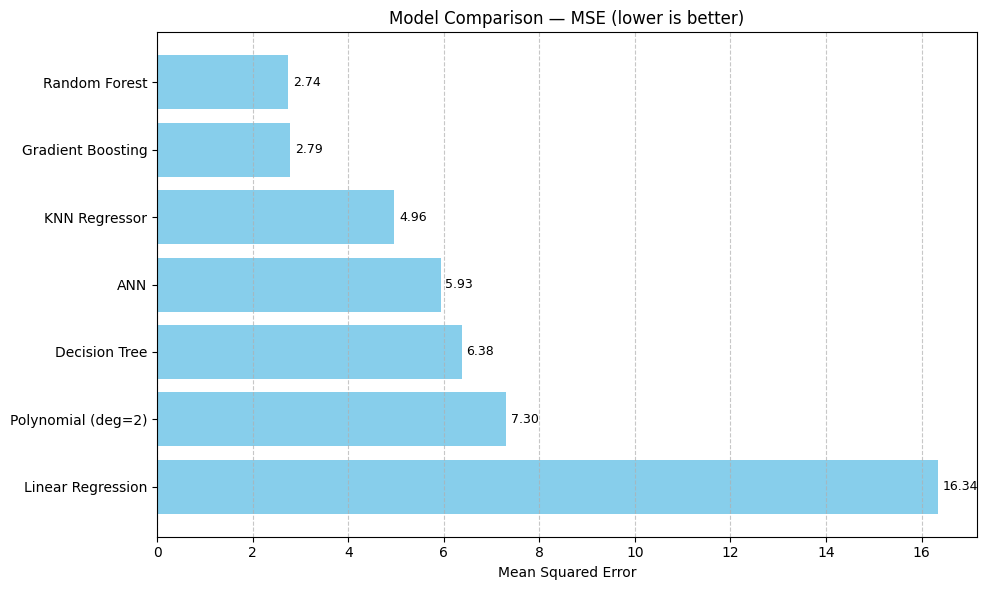

In [3]:
mse_df = results_df.sort_values('MSE')

plt.figure(figsize=(10, 6))
bars = plt.barh(mse_df['Model'], mse_df['MSE'], color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Model Comparison — MSE (lower is better)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.1, bar.get_y() + bar.get_height()/2,
             f'{w:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 3. R² Comparison Chart

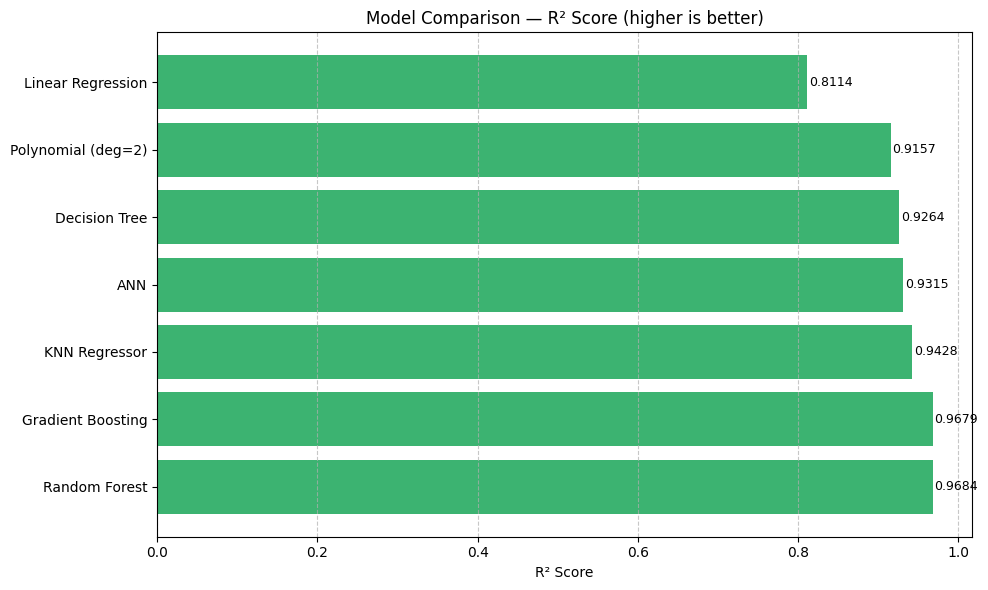

In [4]:
r2_df = results_df.sort_values('R²', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(r2_df['Model'], r2_df['R²'], color='mediumseagreen')
plt.xlabel('R² Score')
plt.title('Model Comparison — R² Score (higher is better)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.002, bar.get_y() + bar.get_height()/2,
             f'{w:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 4. Bonus — Broad Model Sweep (SVR, Lasso, Ridge, MLP)

In [5]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

bonus_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Lasso Regression':  Lasso(alpha=0.1),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN Regressor':     KNeighborsRegressor(n_neighbors=5),
    'SVR (RBF)':         SVR(kernel='rbf'),
    'MLP Regressor':     MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),
}

with open('data/splits.pkl', 'rb') as f:
    X_train_b, X_test_b, y_train_b, y_test_b = pickle.load(f)

bonus_records = []
for name, m in bonus_models.items():
    m.fit(X_train_b, y_train_b)
    p    = m.predict(X_test_b)
    r2   = r2_score(y_test_b, p)
    rmse = np.sqrt(mean_squared_error(y_test_b, p))
    mae  = mean_absolute_error(y_test_b, p)
    bonus_records.append({'Model': name, 'R²': round(r2,4),
                          'RMSE': round(rmse,4), 'MAE': round(mae,4)})

bonus_df = pd.DataFrame(bonus_records).sort_values('R²', ascending=False).reset_index(drop=True)
print(bonus_df.to_string(index=False))


            Model     R²   RMSE    MAE
    Random Forest 0.9685 1.6527 1.0712
    MLP Regressor 0.9207 2.6214 1.8716
    KNN Regressor 0.9036 2.8899 2.0393
        SVR (RBF) 0.8425 3.6942 2.5756
Linear Regression 0.8114 4.0424 2.9586
 Ridge Regression 0.8111 4.0453 2.9576
 Lasso Regression 0.7901 4.2648 3.0567


C:\Users\BIG BOX\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## 5. Conclusions

### Best Model: **Gradient Boosting Regressor**

| Reason | Detail |
|---|---|
| Highest generalisation | R² ≈ 0.968, MAE ≈ 1.11 |
| Handles non-linearity | Captures complex feature interactions |
| Iterative error correction | Each tree corrects the previous one |
| Robust to noisy features | Down-weights uninformative variables |

### Why not KNN / Decision Tree?
Both achieve lower MSE on test data, but exhibit strong **overfitting** —
KNN train score is near perfect (1.00), Decision Tree train score >> test score.

### Key Predictors (from GBR feature importance)
1. **HIV/AIDS** — major direct mortality driver in specific regions
2. **Income composition of resources** — socio-economic development proxy
3. **Adult Mortality** — strong negative linear correlation with life expectancy
4. **Schooling** — strong positive correlation

### Improvement ideas
- Use `log` transform on skewed predictors (GDP, Population, Measles)
- Try `XGBoost` or `LightGBM` as Gradient Boosting alternatives
- Apply SHAP values for more granular feature importance analysis
